在执行工具调用前，暂停执行，以便人工批准、编辑或拒绝。人机参与适用于以下情况：
需要人工批准的高风险操作（例如数据库写入、金融交易）。
必须有人监督的合规工作流程。

In [1]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


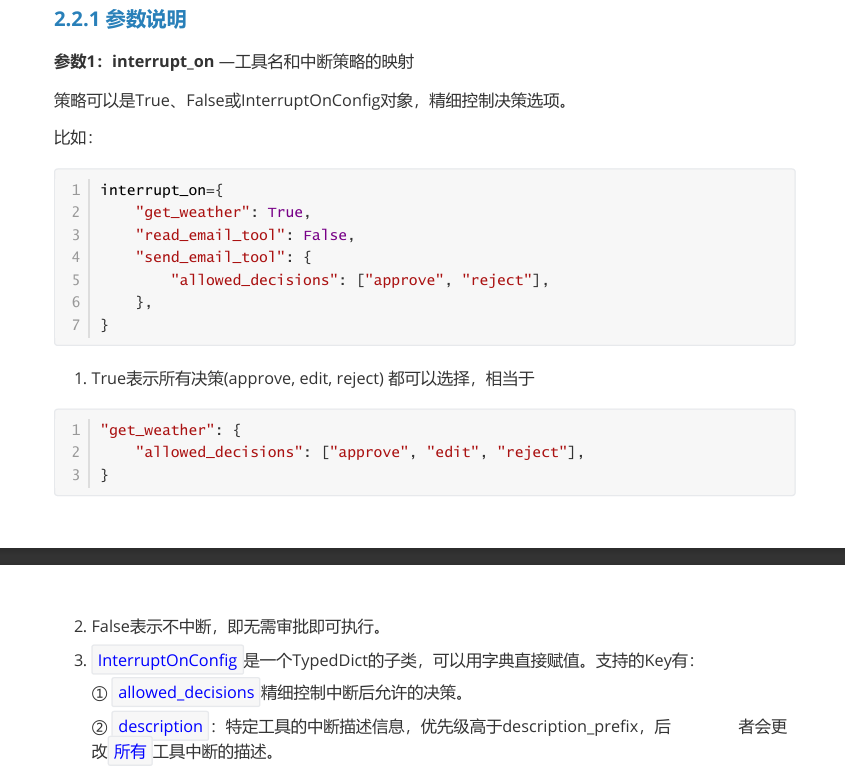
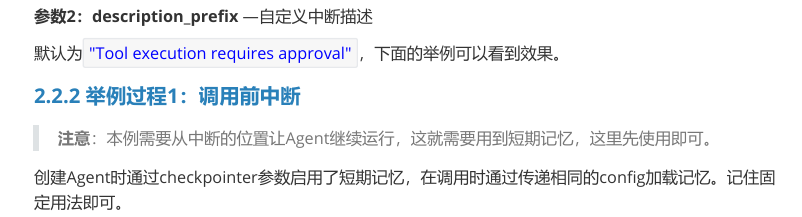
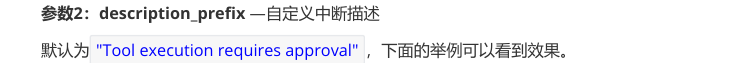

In [3]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage
from langchain.tools import tool
from langgraph.types import Command
from rich import print as rprint


@tool
def get_weather(city: str, is_forcast: bool = False) -> str:
    """
    查询指定城市天气

    Args:
        city: 城市名称
        is_forcast: 是否包含明日天气预报？
    """
    res = f"{city}今天天气不错"
    if is_forcast:
        res += "\n明天下雨"
    return res


@tool
def get_news() -> str:
    """
    查询当日新闻
    """
    return "中方三艘油轮通过霍尔木兹海峡"


@tool
def read_email_tool(email_id: str) -> str:
    """通过邮件ID读取内容的伪函数"""
    return f"邮件ID：{email_id}\n是空的"


@tool
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """发送邮件伪函数"""
    print(">>> 真的执行发送邮件工具了")
    return f"发送给 {recipient} 的邮件标题是：{subject}，内容：{body}"


agent = create_agent(
    model=model,
    tools=[get_weather, get_news, read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),  #开启短期记忆
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "get_weather": True,
                "get_news": True,
                "read_email_tool": False,
                "send_email_tool": {
                    "allowed_decisions": ["approve", "reject"],
                    "description": "发送邮件中断啦"
                },
            },
            description_prefix="中断啦"
        ),
    ],
)
config = {"configurable": {"thread_id": "1"}}
# 第一次调用：会暂停在发送邮件前
response = agent.invoke(
    {
        "messages": [
            HumanMessage(content="请帮我查询今天北京的天气"
                                 "查询今日新闻"
                                 "查看ID为 'sk2131421' 的邮件内容，"
                                 "向15641685664@qq.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'"
                                 "同时做这四件事")
        ]
    },
    config=config,
)

print("==== 第一次 invoke 返回 ====")
print("========= 原始响应 =========")
rprint(response)
print("========= 美化输出 =========")
for msg in response["messages"]:
    msg.pretty_print()
# 关键：看中断信息
interrupts = response.get("__interrupt__", [])
print("========== interrupts ==========")
rprint(interrupts)
# print("==== 逐个打印 interrupt 请求 ====")
action_requests = interrupts[0].value["action_requests"]
for action_request in action_requests:
    rprint(action_request)

==== 第一次 invoke 返回 ====
========= 原始响应 =========


{
    'messages': [
        HumanMessage(
            content="请帮我查询今天北京的天气查询今日新闻查看ID为 'sk2131421' 
的邮件内容，向15641685664@qq.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'同时做这四件事",
            additional_kwargs={},
            response_metadata={},
            id='44b3abd4-e22f-4416-9e16-ffe5dde4e062'
        ),
        AIMessage(
            content='好的，我来同时执行这四件事！',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 176,
                    'prompt_tokens': 514,
                    'total_tokens': 690,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 514
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '559ef675-e585-4ebf-843f-8be59ae03f2e',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f6ae7-8624-7d00-aecf-071fdf5486d4-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_00_XVb44IahAMmZYbrM9Lzg1513',
                    'type': 'tool_call'
                },
                {'name': 'get_news', 'args': {}, 'id': 'call_01_FTMefrn9sSTowC8mTGV72323', 'type': 'tool_call'},
                {
                    'name': 'read_email_tool',
                    'args': {'email_id': 'sk2131421'},
                    'id': 'call_02_5quZQPSJoddnGX8sqxAf3423',
                    'type': 'tool_call'
                },
                {
                    'name': 'send_email_tool',
                    'args': {'recipient': '15641685664@qq.com', 'subject': '哈哈哈', 'body': '你好啊'},
                    'id': 'call_03_bfw2aaCnXcHRAuaFuygC2469',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 514,
                'output_tokens': 176,
                'total_tokens': 690,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ],
    '__interrupt__': [
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'get_weather',
                        'args': {'city': '北京'},
                        'description': "中断啦\n\nTool: get_weather\nArgs: {'city': '北京'}"
                    },
                    {'name': 'get_news', 'args': {}, 'description': '中断啦\n\nTool: get_news\nArgs: {}'},
                    {
                        'name': 'send_email_tool',
                        'args': {'recipient': '15641685664@qq.com', 'subject': '哈哈哈', 'body': '你好啊'},
                        'description': '发送邮件中断啦'
                    }
                ],
                'review_configs': [
                    {'action_name': 'get_weather', 'allowed_decisions': ['approve', 'edit', 'reject']},
                    {'action_name': 'get_news', 'allowed_decisions': ['approve', 'edit', 'reject']},
                    {'action_name': 'send_email_tool', 'allowed_decisions': ['approve', 'reject']}
                ]
            },
            id='69063736debb5dd8f6af2fc55541deeb'
        )
    ]
}

========= 美化输出 =========
================================ Human Message =================================

请帮我查询今天北京的天气查询今日新闻查看ID为 'sk2131421' 的邮件内容，向15641685664@qq.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'同时做这四件事
================================== Ai Message ==================================

好的，我来同时执行这四件事！
Tool Calls:
  get_weather (call_00_XVb44IahAMmZYbrM9Lzg1513)
 Call ID: call_00_XVb44IahAMmZYbrM9Lzg1513
  Args:
    city: 北京
  get_news (call_01_FTMefrn9sSTowC8mTGV72323)
 Call ID: call_01_FTMefrn9sSTowC8mTGV72323
  Args:
  read_email_tool (call_02_5quZQPSJoddnGX8sqxAf3423)
 Call ID: call_02_5quZQPSJoddnGX8sqxAf3423
  Args:
    email_id: sk2131421
  send_email_tool (call_03_bfw2aaCnXcHRAuaFuygC2469)
 Call ID: call_03_bfw2aaCnXcHRAuaFuygC2469
  Args:
    recipient: 15641685664@qq.com
    subject: 哈哈哈
    body: 你好啊
========== interrupts ==========


[
    Interrupt(
        value={
            'action_requests': [
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'description': "中断啦\n\nTool: get_weather\nArgs: {'city': '北京'}"
                },
                {'name': 'get_news', 'args': {}, 'description': '中断啦\n\nTool: get_news\nArgs: {}'},
                {
                    'name': 'send_email_tool',
                    'args': {'recipient': '15641685664@qq.com', 'subject': '哈哈哈', 'body': '你好啊'},
                    'description': '发送邮件中断啦'
                }
            ],
            'review_configs': [
                {'action_name': 'get_weather', 'allowed_decisions': ['approve', 'edit', 'reject']},
                {'action_name': 'get_news', 'allowed_decisions': ['approve', 'edit', 'reject']},
                {'action_name': 'send_email_tool', 'allowed_decisions': ['approve', 'reject']}
            ]
        },
        id='69063736debb5dd8f6af2fc55541deeb'
    )
]

{
    'name': 'get_weather',
    'args': {'city': '北京'},
    'description': "中断啦\n\nTool: get_weather\nArgs: {'city': '北京'}"
}

{'name': 'get_news', 'args': {}, 'description': '中断啦\n\nTool: get_news\nArgs: {}'}

{
    'name': 'send_email_tool',
    'args': {'recipient': '15641685664@qq.com', 'subject': '哈哈哈', 'body': '你好啊'},
    'description': '发送邮件中断啦'
}

2.2.3 举例过程2：指明工具调用请求决策

In [4]:
# 如果有中断，说明进入审核阶段
weather_decision = {
    "type": "edit",
    "edited_action": {
        "name": "get_weather",
        "args": {"city": "中国北京市", "is_forcast": True}
    }
}
news_decision = {
    "type": "approve",
}
send_email_decision = {
    "type": "approve"
}
decisions = {
    "decisions": []
}
# 决策的顺序必须和返回的中断请求顺序一致
for action_request in action_requests:
    if action_request["name"] == "get_weather":
        decisions["decisions"].append(weather_decision)
    if action_request["name"] == "get_news":
        decisions["decisions"].append(news_decision)
    if action_request["name"] == "send_email_tool":
        decisions["decisions"].append(send_email_decision)

if interrupts:
    # 审批通过
    resumed_response = agent.invoke(
        Command(resume=decisions),
        config=config,  # 必须是同一个 thread_id
    )
    print("==== 审批后继续执行 ====")
    for msg in resumed_response["messages"]:
        msg.pretty_print()

>>> 真的执行发送邮件工具了
==== 审批后继续执行 ====
================================ Human Message =================================

请帮我查询今天北京的天气查询今日新闻查看ID为 'sk2131421' 的邮件内容，向15641685664@qq.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'同时做这四件事
================================== Ai Message ==================================

好的，我来同时执行这四件事！
Tool Calls:
  get_weather (call_00_XVb44IahAMmZYbrM9Lzg1513)
 Call ID: call_00_XVb44IahAMmZYbrM9Lzg1513
  Args:
    city: 中国北京市
    is_forcast: True
  get_news (call_01_FTMefrn9sSTowC8mTGV72323)
 Call ID: call_01_FTMefrn9sSTowC8mTGV72323
  Args:
  read_email_tool (call_02_5quZQPSJoddnGX8sqxAf3423)
 Call ID: call_02_5quZQPSJoddnGX8sqxAf3423
  Args:
    email_id: sk2131421
  send_email_tool (call_03_bfw2aaCnXcHRAuaFuygC2469)
 Call ID: call_03_bfw2aaCnXcHRAuaFuygC2469
  Args:
    recipient: 15641685664@qq.com
    subject: 哈哈哈
    body: 你好啊
================================= Tool Message =================================
Name: get_weather

中国北京市今天天气不错
明天下雨
================================= T

练习: 流式调用

In [26]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage
from langchain.tools import tool
from langgraph.types import Command, Interrupt
from rich import print as rprint

# 如果有中断，说明进入审核阶段
weather_decision = {
    "type": "edit",
    "edited_action": {
        "name": "get_weather",
        "args": {"city": "中国北京市", "is_forcast": True}
    }
}
news_decision = {
    "type": "approve",
}
send_email_decision = {
    "type": "approve"
}


@tool
def get_weather(city: str, is_forcast: bool = False) -> str:
    """
    查询指定城市天气

    Args:
        city: 城市名称
        is_forcast: 是否包含明日天气预报？
    """
    res = f"{city}今天天气不错"
    if is_forcast:
        res += "\n明天下雨"
    return res


@tool
def get_news() -> str:
    """
    查询当日新闻
    """
    return "中方三艘油轮通过霍尔木兹海峡"


@tool
def read_email_tool(email_id: str) -> str:
    """通过邮件ID读取内容的伪函数"""
    return f"邮件ID：{email_id}\n是空的"


@tool
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """发送邮件伪函数"""
    print(">>> 真的执行发送邮件工具了")
    return f"发送给 {recipient} 的邮件标题是：{subject}，内容：{body}"


agent = create_agent(
    model=model,
    tools=[get_weather, get_news, read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),  #开启短期记忆
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "get_weather": True,
                "get_news": True,
                "read_email_tool": False,
                "send_email_tool": {
                    "allowed_decisions": ["approve", "reject"],
                    "description": "发送邮件中断啦"
                },
            },
            description_prefix="中断啦"
        ),
    ],
)
config = {"configurable": {"thread_id": "1"}}
# 第一次调用：会暂停在发送邮件前
response = agent.stream(
    {
        "messages": [
            HumanMessage(content="请帮我查询今天北京的天气"
                                 "查询今日新闻"
                                 "查看ID为 'sk2131421' 的邮件内容，"
                                 "向15641685664@qq.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'"
                                 "同时做这四件事")
        ]
    },
    stream_mode="updates",
    config=config,
)

for msg in response:
    rprint(msg)
    # 判断当前是否为中断消息
    if "__interrupt__" in msg:
        # 创建审批决策字典
        decisions = {
            "decisions": []
        }
        # 提取中断信息
        interrupts: Interrupt = msg.get("__interrupt__")

        # 提取中断请求中的 工具详情列表
        action_requests = interrupts[0].value["action_requests"]
        # 提取审核配置
        review_configs = interrupts[0].value["review_configs"]
        # 遍历工具详情列表，根据工具名称判断审批决策
        for map in action_requests:
            #获取工具名称
            tool_name = map["name"]
            if tool_name == "get_weather":
                decisions["decisions"].append(weather_decision)
            if tool_name == "get_news":
                decisions["decisions"].append(news_decision)
            if tool_name == "send_email_tool":
                decisions["decisions"].append(send_email_decision)
        # 将审批结果发送给模型
        response = agent.stream(
            Command(resume=decisions),
            config=config
        )
# 打印结果
for msg in response:
    rprint(msg)









{
    'model': {
        'messages': [
            AIMessage(
                content='我来同时处理这四件事！',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 192,
                        'prompt_tokens': 514,
                        'total_tokens': 706,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 512},
                        'prompt_cache_hit_tokens': 512,
                        'prompt_cache_miss_tokens': 2
                    },
                    'model_provider': 'deepseek',
                    'model_name': 'deepseek-v4-flash',
                    'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                    'id': 'bb736e68-e3ea-4a47-a496-eacddce3258c',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--019f6b5e-2e88-7703-b7b1-66f903615982-0',
                tool_calls=[
                    {
                        'name': 'get_weather',
                        'args': {'city': '北京', 'is_forcast': False},
                        'id': 'call_00_G7u0x3ClrickwaqRVSJI9467',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'get_news',
                        'args': {},
                        'id': 'call_01_AMqWHPLR1EGfZ5vSNNzp8414',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'read_email_tool',
                        'args': {'email_id': 'sk2131421'},
                        'id': 'call_02_NT0bKK2E7ElsiRdVCaPw2813',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'send_email_tool',
                        'args': {'recipient': '15641685664@qq.com', 'subject': '哈哈哈', 'body': '你好啊'},
                        'id': 'call_03_DUpQVR8cSFW7OJE0RIm73370',
                        'type': 'tool_call'
                    }
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 514,
                    'output_tokens': 192,
                    'total_tokens': 706,
                    'input_token_details': {'cache_read': 512},
                    'output_token_details': {}
                }
            )
        ]
    }
}

{
    '__interrupt__': (
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'get_weather',
                        'args': {'city': '北京', 'is_forcast': False},
                        'description': "中断啦\n\nTool: get_weather\nArgs: {'city': '北京', 'is_forcast': False}"
                    },
                    {'name': 'get_news', 'args': {}, 'description': '中断啦\n\nTool: get_news\nArgs: {}'},
                    {
                        'name': 'send_email_tool',
                        'args': {'recipient': '15641685664@qq.com', 'subject': '哈哈哈', 'body': '你好啊'},
                        'description': '发送邮件中断啦'
                    }
                ],
                'review_configs': [
                    {'action_name': 'get_weather', 'allowed_decisions': ['approve', 'edit', 'reject']},
                    {'action_name': 'get_news', 'allowed_decisions': ['approve', 'edit', 'reject']},
                    {'action_name': 'send_email_tool', 'allowed_decisions': ['approve', 'reject']}
                ]
            },
            id='e7f67db176f88168a9dacda5385da817'
        ),
    )
}

{
    'HumanInTheLoopMiddleware.after_model': {
        'messages': [
            AIMessage(
                content='我来同时处理这四件事！',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 192,
                        'prompt_tokens': 514,
                        'total_tokens': 706,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 512},
                        'prompt_cache_hit_tokens': 512,
                        'prompt_cache_miss_tokens': 2
                    },
                    'model_provider': 'deepseek',
                    'model_name': 'deepseek-v4-flash',
                    'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                    'id': 'bb736e68-e3ea-4a47-a496-eacddce3258c',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--019f6b5e-2e88-7703-b7b1-66f903615982-0',
                tool_calls=[
                    {
                        'type': 'tool_call',
                        'name': 'get_weather',
                        'args': {'city': '中国北京市', 'is_forcast': True},
                        'id': 'call_00_G7u0x3ClrickwaqRVSJI9467'
                    },
                    {
                        'name': 'get_news',
                        'args': {},
                        'id': 'call_01_AMqWHPLR1EGfZ5vSNNzp8414',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'read_email_tool',
                        'args': {'email_id': 'sk2131421'},
                        'id': 'call_02_NT0bKK2E7ElsiRdVCaPw2813',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'send_email_tool',
                        'args': {'recipient': '15641685664@qq.com', 'subject': '哈哈哈', 'body': '你好啊'},
                        'id': 'call_03_DUpQVR8cSFW7OJE0RIm73370',
                        'type': 'tool_call'
                    }
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 514,
                    'output_tokens': 192,
                    'total_tokens': 706,
                    'input_token_details': {'cache_read': 512},
                    'output_token_details': {}
                }
            )
        ]
    }
}

>>> 真的执行发送邮件工具了


{
    'tools': {
        'messages': [
            ToolMessage(
                content='中方三艘油轮通过霍尔木兹海峡',
                name='get_news',
                id='27676c12-5724-4481-aee7-8a525f746339',
                tool_call_id='call_01_AMqWHPLR1EGfZ5vSNNzp8414'
            )
        ]
    }
}

{
    'tools': {
        'messages': [
            ToolMessage(
                content='中国北京市今天天气不错\n明天下雨',
                name='get_weather',
                id='cb895cfb-0d3a-4fd5-8c98-9adbd79996b4',
                tool_call_id='call_00_G7u0x3ClrickwaqRVSJI9467'
            )
        ]
    }
}

{
    'tools': {
        'messages': [
            ToolMessage(
                content='邮件ID：sk2131421\n是空的',
                name='read_email_tool',
                id='d960d669-131b-4bbc-8ea4-0a9d62357bd0',
                tool_call_id='call_02_NT0bKK2E7ElsiRdVCaPw2813'
            )
        ]
    }
}

{
    'tools': {
        'messages': [
            ToolMessage(
                content='发送给 15641685664@qq.com 的邮件标题是：哈哈哈，内容：你好啊',
                name='send_email_tool',
                id='4f8efa65-6603-4812-9a5a-1a11ee60bdf0',
                tool_call_id='call_03_DUpQVR8cSFW7OJE0RIm73370'
            )
        ]
    }
}

{
    'model': {
        'messages': [
            AIMessage(
                content='全部完成！以下是四件事的执行结果汇总：\n\n---\n\n### ✅ 1️⃣ 查询北京天气\n- 
**今天天气**：☀️ 天气不错\n- **明日预报**：🌧️ 明天下雨，记得带伞哦！\n\n### ✅ 2️⃣ 查询今日新闻\n- 📰 
**新闻**：中方三艘油轮通过霍尔木兹海峡\n\n### ✅ 3️⃣ 读取邮件（ID: sk2131421）\n- 
该邮件内容为**空的**，没有正文内容。\n\n### ✅ 4️⃣ 发送邮件\n- **收件人**：15641685664@qq.com\n- **标题**：哈哈哈\n-
**内容**：你好啊\n- ✅ **已成功发送！**\n\n---\n\n四件事已经全部并行处理完成！😊',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 169,
                        'prompt_tokens': 793,
                        'total_tokens': 962,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 512},
                        'prompt_cache_hit_tokens': 512,
                        'prompt_cache_miss_tokens': 281
                    },
                    'model_provider': 'deepseek',
                    'model_name': 'deepseek-v4-flash',
                    'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                    'id': '997e2c1d-ff9f-4245-b8f7-61dd84c47a3b',
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='lc_run--019f6b5e-34e9-7c12-a845-1544fc84b71c-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 793,
                    'output_tokens': 169,
                    'total_tokens': 962,
                    'input_token_details': {'cache_read': 512},
                    'output_token_details': {}
                }
            )
        ]
    }
}

{'HumanInTheLoopMiddleware.after_model': None}